# SILVA Fourier Equilibrium: PDE Dataset Lab

This lab develops an input-injected Fourier equilibrium from a periodic
elliptic equation, verifies the generated data against the equation, trains a
small SILVA model, and separates prediction error from equilibrium and
physical residuals.

The state is a field $v\in\mathbb R^{B\times C\times H\times W}$ and the
canonical SILVA family is `silva_fno_deq` [[43]](https://jseluis.github.io/silva-networks/paper/references/#ref-43).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[31]](https://jseluis.github.io/silva-networks/paper/references/#ref-31), [[32]](https://jseluis.github.io/silva-networks/paper/references/#ref-32), [[43]](https://jseluis.github.io/silva-networks/paper/references/#ref-43). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

from silva_networks import (
    SILVAFNODEQ,
    SolverConfig,
    make_periodic_elliptic_dataset,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(170)

## 1. Exact Periodic Elliptic Data

On the unit torus, consider

$$
(-\Delta+m)u=f,
\qquad m>0.
$$

For Fourier wave vector $k$, differentiation gives

$$
\widehat{-\Delta u}(k)=|k|^2\widehat u(k).
$$

Therefore every Fourier coefficient has the exact solution

$$
\widehat u(k)
=\frac{\widehat f(k)}{|k|^2+m}.
$$

`make_periodic_elliptic_dataset` samples a low-mode forcing and evaluates this
formula. It is a deterministic equation dataset rather than a collection of
unverified random input/target pairs.

In [3]:
data = make_periodic_elliptic_dataset(
    samples=8,
    height=8,
    width=8,
    modes=2,
    mass=1.0,
    seed=17,
)
equation_error = data.equation_residual().abs().max()

assert data.forcing.shape == data.target.shape == (8, 1, 8, 8)
assert equation_error < 2e-5
print("forcing:", tuple(data.forcing.shape))
print("maximum dataset equation residual:", float(equation_error))

forcing: (8, 1, 8, 8)
maximum dataset equation residual: 8.58306884765625e-06


## 2. From a Fourier Layer to a SILVA Equilibrium

A retained-mode convolution has the form

$$
\mathcal K_\theta v
=\mathcal F^{-1}
\left(R_\theta(k)\mathcal F(v)(k)\right).
$$

One input-injected internal layer is

$$
v_{j+1}
=g+\sigma\left(W_jv_j+\mathcal K_jv_j+b_j\right),
\qquad g=P_\phi(f).
$$

After composing the internal layers into $B_\theta$, SILVA solves

$$
v^\star=B_\theta(v^\star,P_\phi(f)),
\qquad \widehat u=Q_\psi(v^\star).
$$

The forcing is the source branch, the pointwise channel map is the self branch,
and the spectral convolution is a global field interaction [31, 32, 43].

In [4]:
config = SolverConfig(
    solver="picard",
    max_iter=6,
    tol=1e-5,
    alpha=0.7,
    backward_mode="unrolled",
)
model = SILVAFNODEQ(
    in_channels=1,
    state_channels=4,
    out_channels=1,
    modes_height=2,
    modes_width=2,
    block_depth=1,
    state_scale=0.04,
    config=config,
)
initial = model(data.forcing[:2], return_result=True)

assert initial.output.shape == data.target[:2].shape
print("state:", tuple(initial.state.shape))
print("solver iterations:", initial.solver_result.iterations)
print("equilibrium residual:", initial.solver_result.residual)

state: (2, 4, 8, 8)
solver iterations: 6
equilibrium residual: 0.043956443667411804


## 3. Three Errors, Three Questions

For prediction $\widehat u$, report at least

$$
\mathcal L_{\mathrm{data}}
=\frac1{BHW}\|\widehat u-u\|_2^2,
$$

$$
\epsilon_{\mathrm{eq}}
=\|B_\theta(v^\star,g)-v^\star\|,
$$

and the physical residual

$$
\epsilon_{\mathrm{PDE}}
=\|(-\Delta+m)\widehat u-f\|.
$$

The first measures target fit, the second measures numerical equilibrium, and
the third checks the governing equation. None can substitute for the others.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []
for epoch in range(5):
    optimizer.zero_grad()
    prediction = model(data.forcing[:6])
    loss = torch.nn.functional.mse_loss(prediction, data.target[:6])
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

evaluation = model(data.forcing[6:], return_result=True)
test_mse = torch.nn.functional.mse_loss(evaluation.output, data.target[6:])
test_pde = data.equation_residual(
    torch.cat([data.target[:6], evaluation.output], dim=0)
)[6:].square().mean().sqrt()

assert all(torch.isfinite(torch.tensor(losses)))
assert torch.isfinite(test_mse) and torch.isfinite(test_pde)
print("training losses:", losses)
print("held-out MSE:", float(test_mse))
print("held-out PDE residual:", float(test_pde))
print("held-out equilibrium residual:", evaluation.solver_result.residual)

training losses: [0.4850434362888336, 0.4652763307094574, 0.4460727274417877, 0.4274417459964752, 0.40939149260520935]
held-out MSE: 0.4111410975456238
held-out PDE residual: 93.4570083618164
held-out equilibrium residual: 0.0469677671790123


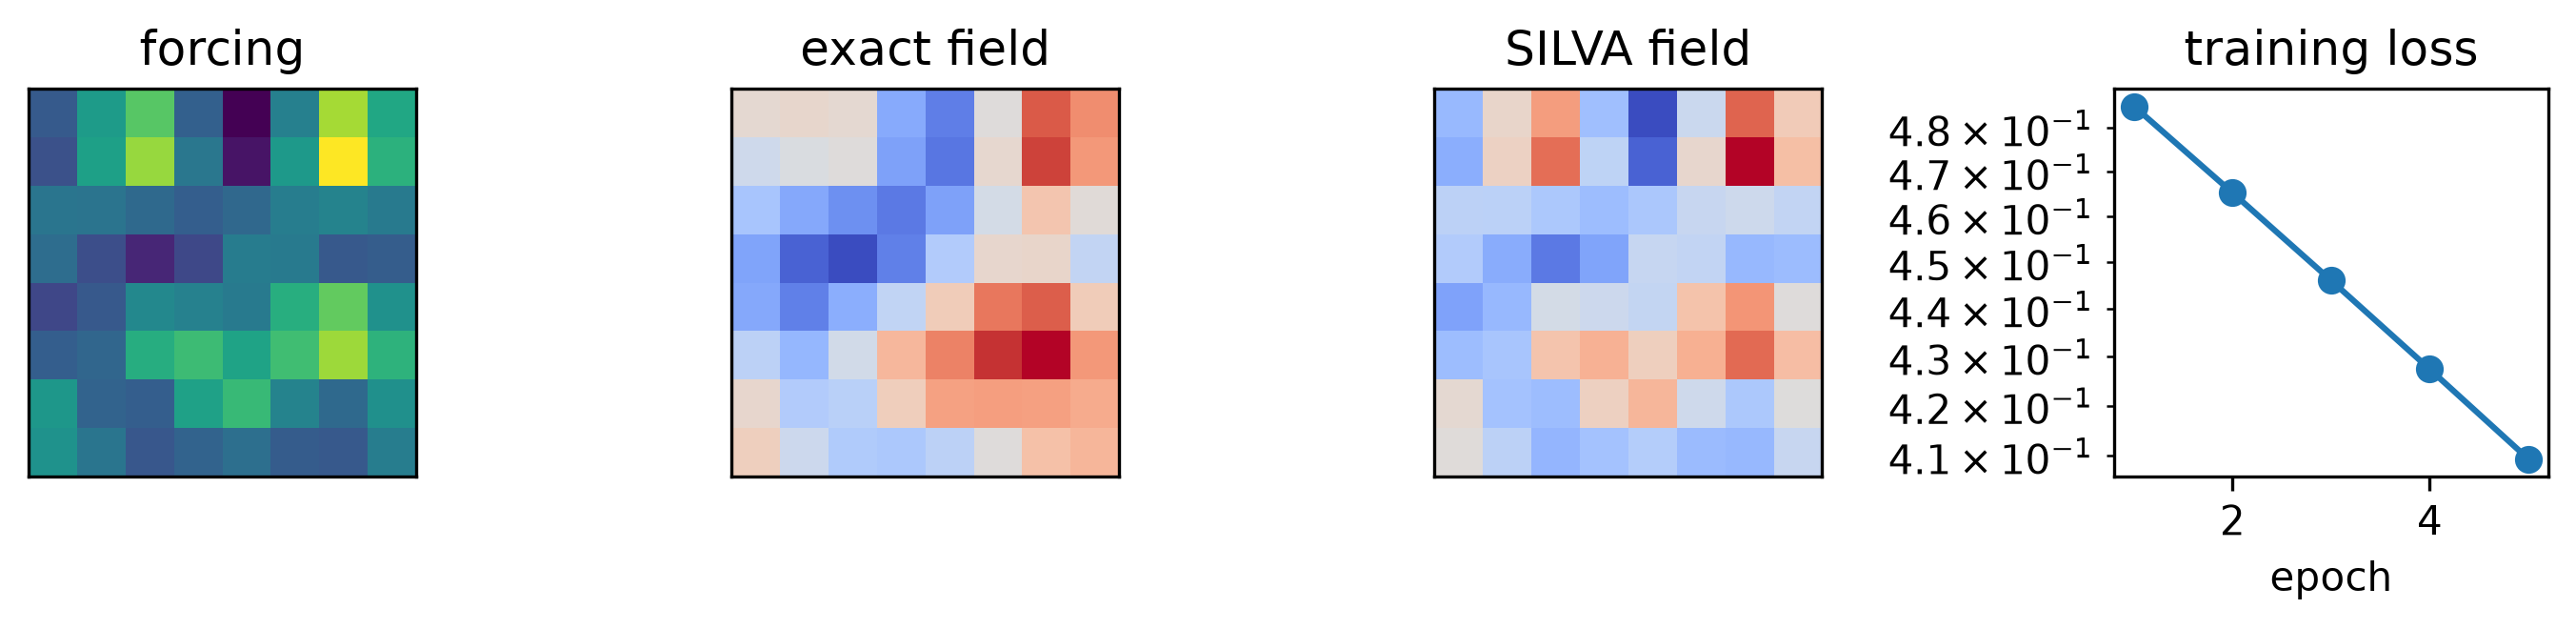

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(9.2, 2.3))
axes[0].imshow(data.forcing[6, 0], cmap="viridis")
axes[0].set_title("forcing")
axes[1].imshow(data.target[6, 0], cmap="coolwarm")
axes[1].set_title("exact field")
axes[2].imshow(evaluation.output[0, 0].detach(), cmap="coolwarm")
axes[2].set_title("SILVA field")
axes[3].plot(range(1, len(losses) + 1), losses, marker="o")
axes[3].set_yscale("log")
axes[3].set_xlabel("epoch")
axes[3].set_title("training loss")
for axis in axes[:3]:
    axis.set_xticks([])
    axis.set_yticks([])
fig.tight_layout()
plt.show()

## 4. Resolution Transfer Is a Testable Contract

The spectral weights are indexed by retained modes, not by the full grid size.
The same model can therefore accept another resolution. This checks shape
compatibility; discretization-invariant accuracy still requires training and
evaluation across resolutions.

In [7]:
fine = make_periodic_elliptic_dataset(
    samples=2,
    height=10,
    width=12,
    modes=2,
    mass=1.0,
    seed=18,
)
fine_result = model(fine.forcing, return_result=True)
assert fine_result.output.shape == (2, 1, 10, 12)
print("new resolution:", tuple(fine_result.output.shape[-2:]))
print("new-resolution residual:", fine_result.solver_result.residual)

new resolution: (10, 12)
new-resolution residual: 0.06008799001574516


## 5. Factory and Extension Points

The canonical factory key keeps the model under SILVA. A custom readout may
enforce boundary values or decode several physical variables. A custom block
must preserve field shape and continue to inject the forcing during every
tied application.

In [8]:
factory_model = silva_equilibrium_model(
    "silva_fno_deq",
    in_channels=1,
    state_channels=3,
    out_channels=1,
    modes_height=2,
    modes_width=2,
    config=SolverConfig(max_iter=4, alpha=0.7),
)
factory_output = factory_model(data.forcing[:1])
assert factory_output.shape == data.target[:1].shape
print(type(factory_model).__name__)

SILVAFNODEQ


## 6. Practical Guidance

| Symptom | Check first | Typical response |
|---|---|---|
| equilibrium residual stalls | state scale and solver damping | reduce recurrent scale or damping step |
| PDE residual is high but MSE is low | physical discretization and loss | add equation-aware validation or training |
| fine-grid error grows | train/test resolution distribution | train across grids and report each resolution |
| boundary artifacts appear | boundary representation | use padding, coordinate channels, or an explicit boundary map |

The compact dataset validates implementation and teaching claims. Large Darcy
or steady Navier-Stokes comparisons require the exact benchmark split,
normalization, architecture scale, and reporting protocol used by the study
[[43]](https://jseluis.github.io/silva-networks/paper/references/#ref-43).

## From 17 Silva Fno Equilibrium Lab to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a sampled solution field on a grid or mesh |
| Condition | coefficient, forcing, boundary, and coordinate fields |
| Repeated computation | a tied local/spectral/operator field with source reinjection |
| Required invariants | spatial shape, boundary conditions, and resolution semantics |
| Replaceable components | lifting map, spectral/local operator, physics field, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace the Lift, Tied Field, and Readout

```python
class MyTiedOperator(nn.Module):
    def forward(self, state, lifted_forcing):
        spectral = self.spectral_operator(state)
        local = self.local_operator(state)
        return torch.tanh(lifted_forcing + spectral + local)


model = SILVAFNODEQ(
    in_channels=forcing_channels,
    state_channels=width,
    out_channels=solution_channels,
    forcing_lift=my_lift,
    block=MyTiedOperator(),
    readout=my_readout,
    config=solver_config,
)
```


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**solution error, PDE residual, boundary error, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **resolution, retained modes, channels, domain size, and dataset size**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '17_silva_fno_equilibrium_lab.ipynb',
    "state": 'a sampled solution field on a grid or mesh',
    "condition": 'coefficient, forcing, boundary, and coordinate fields',
    "transition": 'a tied local/spectral/operator field with source reinjection',
    "invariants": 'spatial shape, boundary conditions, and resolution semantics',
    "compact_metric": 'solution error, PDE residual, boundary error, and fixed-point residual',
    "scale_axis": 'resolution, retained modes, channels, domain size, and dataset size',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '17_silva_fno_equilibrium_lab.ipynb',
 'state': 'a sampled solution field on a grid or mesh',
 'condition': 'coefficient, forcing, boundary, and coordinate fields',
 'transition': 'a tied local/spectral/operator field with source reinjection',
 'invariants': 'spatial shape, boundary conditions, and resolution semantics',
 'compact_metric': 'solution error, PDE residual, boundary error, and fixed-point residual',
 'scale_axis': 'resolution, retained modes, channels, domain size, and dataset size'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **operator feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a sampled solution field on a grid or mesh**, and its repeated map,
**a tied local/spectral/operator field with source reinjection**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('operator feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


operator feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


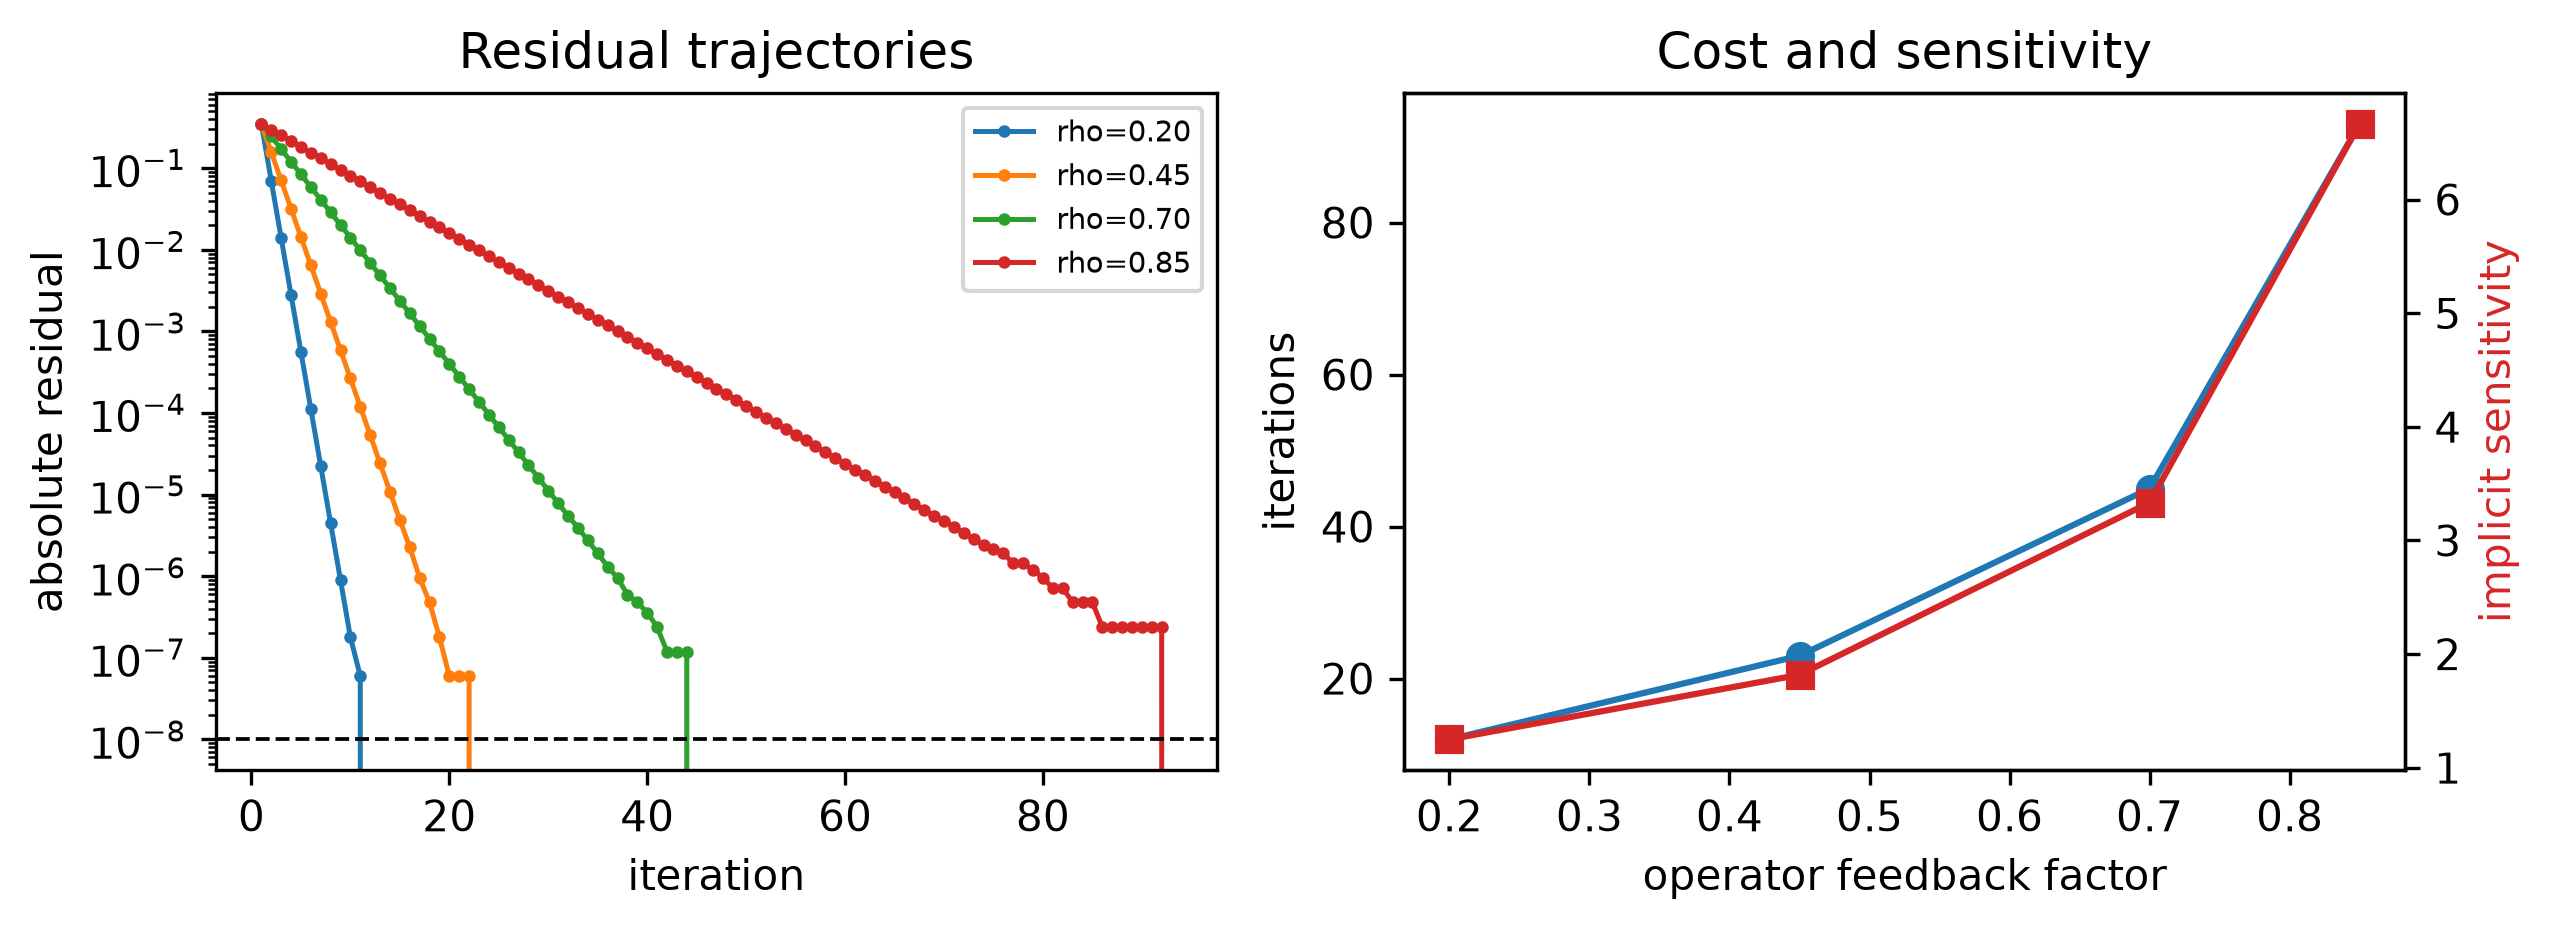

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('operator feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the operator feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | solution error, PDE residual, boundary error, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | spatial shape, boundary conditions, and resolution semantics |
| Scale sweep | Change one of resolution, retained modes, channels, domain size, and dataset size at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How was the periodic PDE dataset constructed? | [Dataset-Backed Equilibrium Labs](https://jseluis.github.io/silva-networks/learn/frontier-dataset-labs/#periodic-elliptic-fields) |
| How does the Fourier family fit the SILVA grammar? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/#silva-fourier-equilibrium) |
| Which dataset builders are public? | [Recent Dataset API](https://jseluis.github.io/silva-networks/api/frontier_data/) |
